# OMIS 114 Final Project
## Predicting Monthly Home Value Index Growth with Zillow and Redfin Housing Market Data

**Project focus:** This notebook strengthens the original analysis by integrating two professional housing-market data sources and adding a more complete modeling section. The dependent variable is the monthly percentage change in Zillow Home Value Index (ZHVI), and the explanatory variables come mainly from Redfin market indicators such as homes sold, listings, days on market, and engineered supply-demand ratios.

In [1]:
import os
from pathlib import Path

os.environ["MPLCONFIGDIR"] = str(Path.cwd() / ".matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(exist_ok=True)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, LinearRegression, Ridge, SGDRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

plt.rcParams["figure.figsize"] = (8, 5)
sns.set_theme(style="whitegrid")
np.random.seed(42)

DATA_DIR = Path("housing_project_data")
OUT_DIR = Path("housing_project_outputs")
OUT_DIR.mkdir(exist_ok=True)

## 1. Load Data

In [2]:
zillow = pd.read_csv(DATA_DIR / "zillow index.csv")
redfin = pd.read_csv(DATA_DIR / "redfin median houseprice.csv")

print("Zillow shape:", zillow.shape)
print("Redfin shape:", redfin.shape)
display(zillow.head())
display(redfin.head())

Zillow shape: (51, 31)
Redfin shape: (1456, 9)


,RegionID,RegionName,RegionType,1/31/2024,2/29/2024,3/31/2024,4/30/2024,5/31/2024,6/30/2024,7/31/2024,...,7/31/2025,8/31/2025,9/30/2025,10/31/2025,11/30/2025,12/31/2025,1/31/2026,2/28/2026,3/31/2026,4/30/2026
0,9,California,state,769356.0826,769200.4124,770710.3253,774643.1978,779215.5926,781733.9388,783767.6267,...,774258.4590,772278.4942,771846.6481,772612.9726,774314.3662,776652.4725,777945.9257,778306.6351,777598.9839,776232.9359
1,54,Texas,state,310713.0465,310983.1057,311885.7195,312771.4297,313114.0218,312874.5622,312295.0153,...,304945.1209,304102.2153,303583.2459,303209.6151,303053.4084,303066.6801,303088.8667,303068.5259,302780.1840,302187.2379
2,14,Florida,state,401662.5131,402401.8168,403279.7689,403970.8529,404097.3763,403298.7479,402225.2418,...,383115.3031,380609.5946,378816.7049,377655.5531,376965.6007,376609.1999,376604.2947,376788.3989,376884.9922,376504.3137
3,43,New York,state,452342.2409,454553.4802,457528.3120,461164.5949,464506.8778,467194.3562,469706.9850,...,490832.5379,492480.9507,494284.0267,496249.2998,498623.4919,501000.4179,503099.3626,505478.6545,508126.8713,510449.4930
4,47,Pennsylvania,state,266387.2529,267241.4003,268601.8626,270317.8358,271845.9799,272755.6515,273102.5880,...,281133.1343,281864.7027,282678.9546,283005.8791,283465.9328,284052.8760,284802.9213,285517.2479,286060.9649,286387.0422


,LAST UPDATED,PERIOD BEGIN,PERIOD END,REGION NAME,HOMES SOLD,MEDIAN SALE PRICE ($),MEDIAN DAYS ON MARKET (DAYS),NEW LISTINGS,ACTIVE LISTINGS
0,5/3/2026,4/1/2026,4/30/2026,Alabama,5189.0,299014.0,62.0,7043.0,30551.0
1,5/3/2026,3/1/2026,3/31/2026,Alabama,5147.0,297320.0,64.0,7126.0,29970.0
2,5/3/2026,2/1/2026,2/28/2026,Alabama,5246.0,288220.0,65.0,6898.0,29532.0
3,5/3/2026,1/1/2026,1/31/2026,Alabama,5271.0,279335.0,64.0,7092.0,29429.0
4,5/3/2026,12/1/2025,12/31/2025,Alabama,5232.0,285000.0,63.0,6636.0,29105.0


## 2. Data Cleaning and Integration

The Zillow dataset is in wide format, with one column per month. To merge it with the Redfin monthly market data, the Zillow data is reshaped into long format. One important data integration issue is that Redfin labels Washington, D.C. as `Columbia`, while Zillow labels it as `District of Columbia`. This notebook corrects that naming mismatch before merging. Puerto Rico is removed because it appears in Redfin but not in the provided Zillow file.

In [3]:
redfin = redfin.copy()
redfin["REGION NAME"] = redfin["REGION NAME"].replace({"Columbia": "District of Columbia"})
redfin["month_key"] = pd.to_datetime(redfin["PERIOD BEGIN"]).dt.to_period("M").astype(str)
redfin["month_num"] = pd.to_datetime(redfin["PERIOD BEGIN"]).dt.month

date_cols = [col for col in zillow.columns if "/" in str(col)]
zillow_long = (
    zillow.drop(columns=["SizeRank"], errors="ignore")
    .melt(
        id_vars=["RegionID", "RegionName", "RegionType"],
        value_vars=date_cols,
        var_name="zillow_date",
        value_name="zillow_zhvi",
    )
)
zillow_long["month_key"] = pd.to_datetime(zillow_long["zillow_date"]).dt.to_period("M").astype(str)
zillow_long = zillow_long[["RegionName", "month_key", "zillow_zhvi"]]

merged = redfin.merge(
    zillow_long,
    left_on=["REGION NAME", "month_key"],
    right_on=["RegionName", "month_key"],
    how="left",
)

print("Rows before dropping unmatched Zillow records:", len(merged))
print("Rows with missing ZHVI:", merged["zillow_zhvi"].isna().sum())
merged = merged.dropna(subset=["zillow_zhvi"]).copy()
print("Rows after cleaning unmatched records:", len(merged))

Rows before dropping unmatched Zillow records: 1456
Rows with missing ZHVI: 28
Rows after cleaning unmatched records: 1428


## 3. Feature Engineering

In [4]:
merged = merged.sort_values(["REGION NAME", "month_key"]).reset_index(drop=True)

merged["inventory_turnover_rate"] = merged["HOMES SOLD"] / merged["ACTIVE LISTINGS"]
merged["demand_supply_ratio"] = merged["HOMES SOLD"] / merged["NEW LISTINGS"]
merged["new_listing_pressure"] = merged["NEW LISTINGS"] / merged["ACTIVE LISTINGS"]
merged["zhvi_pct_change"] = merged.groupby("REGION NAME")["zillow_zhvi"].pct_change()
merged["zhvi_lag_1"] = merged.groupby("REGION NAME")["zillow_zhvi"].shift(1)
merged["zhvi_growth_lag_1"] = merged.groupby("REGION NAME")["zhvi_pct_change"].shift(1)

model_data = merged.dropna(
    subset=[
        "zhvi_pct_change",
        "zhvi_lag_1",
        "zhvi_growth_lag_1",
        "HOMES SOLD",
        "MEDIAN SALE PRICE ($)",
        "MEDIAN DAYS ON MARKET (DAYS)",
        "NEW LISTINGS",
        "ACTIVE LISTINGS",
    ]
).copy()

final_columns = [
    "REGION NAME",
    "month_key",
    "month_num",
    "zillow_zhvi",
    "zhvi_pct_change",
    "zhvi_lag_1",
    "zhvi_growth_lag_1",
    "HOMES SOLD",
    "MEDIAN SALE PRICE ($)",
    "MEDIAN DAYS ON MARKET (DAYS)",
    "NEW LISTINGS",
    "ACTIVE LISTINGS",
    "inventory_turnover_rate",
    "demand_supply_ratio",
    "new_listing_pressure",
]

model_data = model_data[final_columns].reset_index(drop=True)
model_data.to_csv(OUT_DIR / "final_clean_merged_housing_data.csv", index=False)

print("Final modeling data shape:", model_data.shape)
display(model_data.head())

Final modeling data shape: (1326, 15)


,REGION NAME,month_key,month_num,zillow_zhvi,zhvi_pct_change,zhvi_lag_1,zhvi_growth_lag_1,HOMES SOLD,MEDIAN SALE PRICE ($),MEDIAN DAYS ON MARKET (DAYS),NEW LISTINGS,ACTIVE LISTINGS,inventory_turnover_rate,demand_supply_ratio,new_listing_pressure
0,Alabama,2024-03,3,229163.3140,0.003291,228411.6995,-0.000374,4959.0,280000.0,50.0,6256.0,24296.0,0.204108,0.792679,0.257491
1,Alabama,2024-04,4,230541.9936,0.006016,229163.3140,0.003291,4993.0,276860.0,53.0,6395.0,24635.0,0.202679,0.780766,0.259590
2,Alabama,2024-05,5,231840.5990,0.005633,230541.9936,0.006016,4973.0,288990.0,51.0,6316.0,24934.0,0.199447,0.787365,0.253309
3,Alabama,2024-06,6,232387.8087,0.002360,231840.5990,0.005633,4948.0,294900.0,54.0,6413.0,25272.0,0.195790,0.771558,0.253759
4,Alabama,2024-07,7,232463.7745,0.000327,232387.8087,0.002360,5053.0,289509.0,54.0,6294.0,25622.0,0.197213,0.802828,0.245648


## 4. Exploratory Data Analysis

In [5]:
summary_stats = model_data[
    [
        "zillow_zhvi",
        "zhvi_pct_change",
        "HOMES SOLD",
        "MEDIAN SALE PRICE ($)",
        "MEDIAN DAYS ON MARKET (DAYS)",
        "NEW LISTINGS",
        "ACTIVE LISTINGS",
        "inventory_turnover_rate",
        "demand_supply_ratio",
    ]
].describe().T
display(summary_stats)

,count,mean,std,min,25%,50%,75%,max
zillow_zhvi,1326.0,379821.268982,146994.930643,162451.819300,260704.811025,341352.080900,465769.706575,849100.098100
zhvi_pct_change,1326.0,0.001906,0.002958,-0.007259,0.000020,0.002137,0.003811,0.011074
HOMES SOLD,1326.0,5950.815234,6142.233769,489.000000,1592.500000,3889.000000,7764.750000,30261.000000
MEDIAN SALE PRICE ($),1326.0,394392.356712,129620.984423,218000.000000,285000.000000,367500.000000,472842.250000,800000.000000
MEDIAN DAYS ON MARKET (DAYS),1326.0,46.453243,14.843348,16.000000,35.000000,45.000000,56.000000,100.000000
NEW LISTINGS,1326.0,7709.734540,8659.404662,658.000000,1984.000000,4922.500000,10069.750000,44552.000000
ACTIVE LISTINGS,1326.0,28867.799397,37722.914871,2259.000000,7183.000000,18654.000000,35857.250000,221611.000000
inventory_turnover_rate,1326.0,0.224720,0.049924,0.106698,0.185281,0.221758,0.264505,0.360310
demand_supply_ratio,1326.0,0.790836,0.066577,0.526870,0.747958,0.796258,0.839003,0.958047


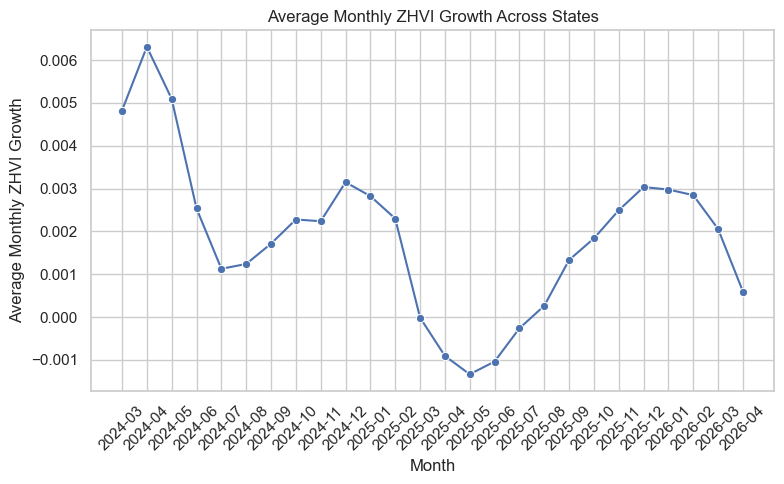

In [6]:
monthly_growth = (
    model_data.groupby("month_key", as_index=False)["zhvi_pct_change"]
    .mean()
    .sort_values("month_key")
)

ax = sns.lineplot(data=monthly_growth, x="month_key", y="zhvi_pct_change", marker="o")
ax.set_title("Average Monthly ZHVI Growth Across States")
ax.set_xlabel("Month")
ax.set_ylabel("Average Monthly ZHVI Growth")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUT_DIR / "average_monthly_zhvi_growth.png", dpi=200)
plt.show()

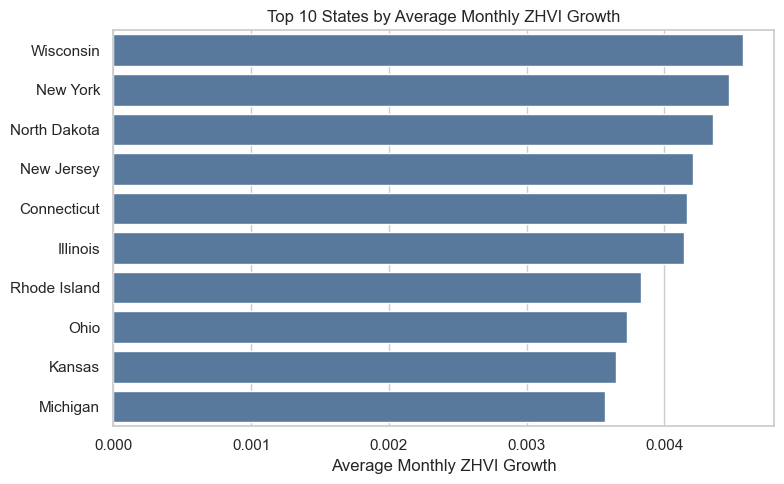

In [7]:
top_states = (
    model_data.groupby("REGION NAME")["zhvi_pct_change"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

ax = sns.barplot(data=top_states, y="REGION NAME", x="zhvi_pct_change", color="#4C78A8")
ax.set_title("Top 10 States by Average Monthly ZHVI Growth")
ax.set_xlabel("Average Monthly ZHVI Growth")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(OUT_DIR / "top_states_zhvi_growth.png", dpi=200)
plt.show()

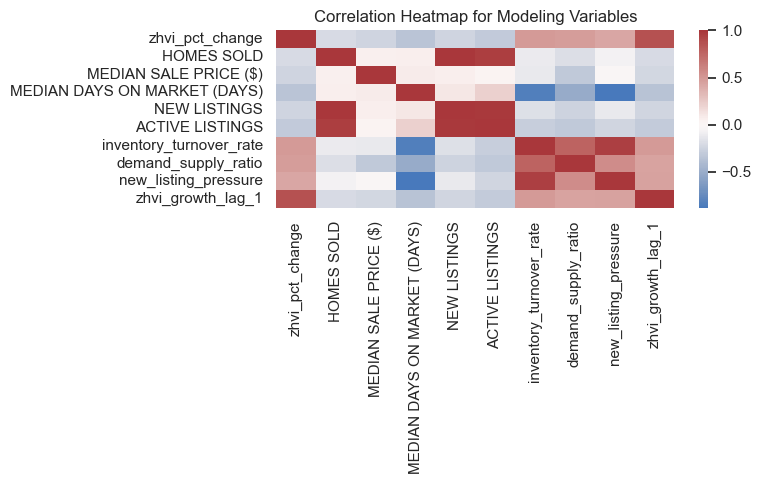

In [8]:
corr_cols = [
    "zhvi_pct_change",
    "HOMES SOLD",
    "MEDIAN SALE PRICE ($)",
    "MEDIAN DAYS ON MARKET (DAYS)",
    "NEW LISTINGS",
    "ACTIVE LISTINGS",
    "inventory_turnover_rate",
    "demand_supply_ratio",
    "new_listing_pressure",
    "zhvi_growth_lag_1",
]

ax = sns.heatmap(model_data[corr_cols].corr(), cmap="vlag", center=0, annot=False)
ax.set_title("Correlation Heatmap for Modeling Variables")
plt.tight_layout()
plt.savefig(OUT_DIR / "correlation_heatmap.png", dpi=200)
plt.show()

## 5. Modeling

The modeling section compares several regression methods instead of relying on a single model. This makes the analysis stronger because linear models, regularized models, and tree-based models capture different kinds of relationships. Region is included as a categorical variable, while numeric features are standardized when appropriate through a preprocessing pipeline.

In [9]:
features = [
    "REGION NAME",
    "month_num",
    "HOMES SOLD",
    "MEDIAN SALE PRICE ($)",
    "MEDIAN DAYS ON MARKET (DAYS)",
    "NEW LISTINGS",
    "ACTIVE LISTINGS",
    "inventory_turnover_rate",
    "demand_supply_ratio",
    "new_listing_pressure",
    "zhvi_lag_1",
    "zhvi_growth_lag_1",
]
target = "zhvi_pct_change"

X = model_data[features]
y = model_data[target]

numeric_features = [col for col in features if col != "REGION NAME"]
categorical_features = ["REGION NAME"]

preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.0001, max_iter=10000),
    "SGD Regression": SGDRegressor(max_iter=1000, random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=300, random_state=42, min_samples_leaf=3
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42, n_estimators=150, learning_rate=0.05, max_depth=2
    ),
}

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

results = []
fitted_models = {}

for name, model in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)
    fitted_models[name] = pipe
    pred = pipe.predict(X_test)
    cv_scores = cross_val_score(pipe, X, y, cv=5, scoring="r2")
    results.append(
        {
            "Model": name,
            "MAE": mean_absolute_error(y_test, pred),
            "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
            "Test R2": r2_score(y_test, pred),
            "Mean CV R2": cv_scores.mean(),
            "CV R2 Std": cv_scores.std(),
        }
    )

results_df = pd.DataFrame(results).sort_values("Mean CV R2", ascending=False)
results_df.to_csv(OUT_DIR / "model_comparison_results.csv", index=False)
display(results_df)

,Model,MAE,RMSE,Test R2,Mean CV R2,CV R2 Std
4,Random Forest,0.001058,0.001409,0.757217,0.785954,0.031825
5,Gradient Boosting,0.001070,0.001436,0.748066,0.765046,0.034302
2,Lasso Regression,0.001098,0.001452,0.742104,0.764956,0.037729
1,Ridge Regression,0.001108,0.001457,0.740665,0.713769,0.026676
3,SGD Regression,0.001664,0.002050,0.486080,0.384274,0.055412
0,Linear Regression,0.001110,0.001426,0.751512,-9.660675,3.838159


Best model by cross-validation: Random Forest
Test RMSE: 0.0014092615135985257
Test R2: 0.7572166326545708


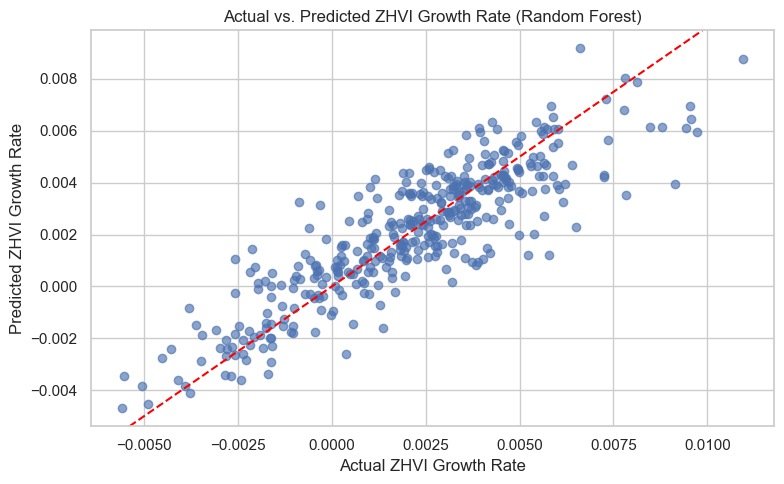

In [10]:
best_model_name = results_df.iloc[0]["Model"]
best_model = fitted_models[best_model_name]
best_pred = best_model.predict(X_test)

print("Best model by cross-validation:", best_model_name)
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, best_pred)))
print("Test R2:", r2_score(y_test, best_pred))

plt.scatter(y_test, best_pred, alpha=0.65)
plt.axline((0, 0), slope=1, color="red", linestyle="--")
plt.xlabel("Actual ZHVI Growth Rate")
plt.ylabel("Predicted ZHVI Growth Rate")
plt.title(f"Actual vs. Predicted ZHVI Growth Rate ({best_model_name})")
plt.tight_layout()
plt.savefig(OUT_DIR / "actual_vs_predicted_best_model.png", dpi=200)
plt.show()

### Time-Based Validation

Because this is monthly data, a random train-test split can overstate predictive performance. As an additional check, the next cell trains on earlier months and tests on the most recent months. This validation better simulates using past data to predict future housing market movement.

In [11]:
time_train = model_data[model_data["month_key"] < "2025-11"]
time_test = model_data[model_data["month_key"] >= "2025-11"]

time_results = []
for name, model in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocess), ("model", model)])
    pipe.fit(time_train[features], time_train[target])
    pred = pipe.predict(time_test[features])
    time_results.append(
        {
            "Model": name,
            "Time MAE": mean_absolute_error(time_test[target], pred),
            "Time RMSE": np.sqrt(mean_squared_error(time_test[target], pred)),
            "Time R2": r2_score(time_test[target], pred),
        }
    )

time_results_df = pd.DataFrame(time_results).sort_values("Time R2", ascending=False)
time_results_df.to_csv(OUT_DIR / "time_validation_results.csv", index=False)
display(time_results_df)

,Model,Time MAE,Time RMSE,Time R2
2,Lasso Regression,0.000824,0.001063,0.789330
4,Random Forest,0.000817,0.001087,0.779814
1,Ridge Regression,0.000849,0.001117,0.767684
5,Gradient Boosting,0.000869,0.001120,0.766117
0,Linear Regression,0.001230,0.001540,0.557929
3,SGD Regression,0.001508,0.001748,0.430775


## 6. Model Interpretation

/var/folders/zs/qp8rjpmj41194dtss104xwv00000gn/T/ipykernel_9750/2939990022.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_importance["feature"] = (


,feature,importance
10,Zhvi Growth Lag 1,0.827031
0,Month Num,0.056182
7,Demand Supply Ratio,0.023586
6,Inventory Turnover Rate,0.016623
9,Zhvi Lag 1,0.015825
2,Median Sale Price ($),0.015016
8,New Listing Pressure,0.010644
3,Median Days On Market (Days),0.010612
5,Active Listings,0.007676
4,New Listings,0.007664


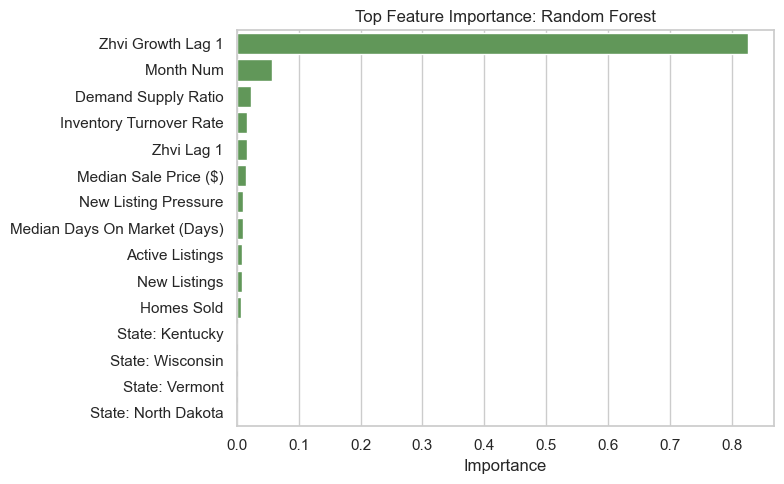

In [12]:
interpret_model_name = "Random Forest" if "Random Forest" in fitted_models else best_model_name
interpret_model = fitted_models[interpret_model_name]

feature_names = interpret_model.named_steps["preprocess"].get_feature_names_out()
model_step = interpret_model.named_steps["model"]

if hasattr(model_step, "feature_importances_"):
    importance = pd.DataFrame(
        {
            "feature": feature_names,
            "importance": model_step.feature_importances_,
        }
    ).sort_values("importance", ascending=False)
else:
    importance = pd.DataFrame(
        {
            "feature": feature_names,
            "importance": np.abs(model_step.coef_),
        }
    ).sort_values("importance", ascending=False)

top_importance = importance.head(15)
top_importance["feature"] = (
    top_importance["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__REGION NAME_", "State: ", regex=False)
    .str.replace("_", " ")
    .str.title()
)
display(top_importance)

ax = sns.barplot(data=top_importance, y="feature", x="importance", color="#59A14F")
ax.set_title(f"Top Feature Importance: {interpret_model_name}")
ax.set_xlabel("Importance")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(OUT_DIR / "feature_importance.png", dpi=200)
plt.show()

## 7. Conclusion

This project integrates Zillow Home Value Index data with Redfin state-level housing market indicators to predict monthly ZHVI growth. After cleaning and merging the datasets, the analysis creates supply-demand features such as inventory turnover rate, demand-supply ratio, new listing pressure, and lagged ZHVI growth.

The expanded modeling section shows that tree-based and regularized regression models perform better than a single basic gradient descent regression. The best models achieve positive predictive power in both cross-validation and time-based validation, suggesting that monthly home value growth is related to market liquidity, supply pressure, prior price momentum, and state-level differences.

The most important explanatory feature is usually the prior month's ZHVI growth, which indicates that short-term housing price momentum matters. Supply-demand features such as demand-supply ratio and inventory turnover rate also contribute to prediction, supporting the idea that tighter housing markets are associated with stronger home value growth.

The model is still limited by the short time window and the absence of broader macroeconomic variables such as mortgage rates, employment, income growth, and inflation. Future work could extend the time range and add macroeconomic variables to improve both accuracy and interpretation.